# TP Méthodes d'Ensemble - Partie 1 : Arbre de Décision from scratch

Implémenter un arbre de décision vous-même et le visualiser.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree


## 1. Chargement des données


In [31]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')
df = df.dropna()
df['target'] = (df['target'] > 0).astype(int)

X = df.drop('target', axis=1).values
y = df['target'].values
feature_names = df.drop('target', axis=1).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Echantillons : {len(df)}")
print(f"Features     : {len(feature_names)}")


Echantillons : 297
Features     : 13


## 2. Classe pour representer un noeud de l'arbre


In [32]:
class DecisionTreeNode:
    """Represente un noeud de l'arbre de decision (interne ou feuille)."""
    
    def __init__(self, feature=None, threshold=None, left=None, right=None, 
                 predicted_class=None, n_samples=0, class_counts=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.predicted_class = predicted_class
        self.n_samples = n_samples
        self.class_counts = class_counts
    
    def is_leaf(self):
        return self.predicted_class is not None


## 3. Calcul de l'impurete (Gini ou Entropie)



In [33]:
def gini_impurity(y):
    """Calcule l'indice de Gini : Gini(S) = 1 - sum(p_i^2)"""
    if len(y) == 0:
        return 0
    
    _, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return 1 - np.sum(proportions ** 2)


def entropy(y):
    """Calcule l'entropie : H(S) = -sum(p_i * log2(p_i))"""
    if len(y) == 0:
        return 0
    
    _, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    proportions = proportions[proportions > 0]
    return -np.sum(proportions * np.log2(proportions))


## 4. Trouver le meilleur split


In [34]:
def find_best_split(X, y, criterion='gini'):
    """Trouve la meilleure feature et seuil pour separer les donnees."""
    n_samples, n_features = X.shape
    impurity_func = gini_impurity if criterion == 'gini' else entropy
    parent_impurity = impurity_func(y)
    
    best_gain = 0
    best_feature = None
    best_threshold = None
    
    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx])
        
        for threshold in thresholds:
            left_mask = X[:, feature_idx] <= threshold
            right_mask = ~left_mask
            
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue
            
            left_impurity = impurity_func(y[left_mask])
            right_impurity = impurity_func(y[right_mask])
            
            n_left = np.sum(left_mask)
            n_right = np.sum(right_mask)
            weighted_impurity = (n_left * left_impurity + n_right * right_impurity) / n_samples
            
            gain = parent_impurity - weighted_impurity
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold
    
    return best_feature, best_threshold, best_gain


## 5. Construction recursive de l'arbre


In [35]:
def build_tree(X, y, depth=0, max_depth=5, min_samples_split=2, criterion='gini'):
    """Construit recursivement l'arbre de decision."""
    n_samples = len(y)
    n_classes = len(np.unique(y))
    
    class_counts = [np.sum(y == c) for c in range(2)]
    majority_class = np.argmax(class_counts)
    
    if depth >= max_depth or n_classes == 1 or n_samples < min_samples_split:
        return DecisionTreeNode(
            predicted_class=majority_class,
            n_samples=n_samples,
            class_counts=class_counts
        )
    
    best_feature, best_threshold, best_gain = find_best_split(X, y, criterion)
    
    if best_gain == 0:
        return DecisionTreeNode(
            predicted_class=majority_class,
            n_samples=n_samples,
            class_counts=class_counts
        )
    
    left_mask = X[:, best_feature] <= best_threshold
    right_mask = ~left_mask
    
    left_subtree = build_tree(X[left_mask], y[left_mask], 
                              depth + 1, max_depth, min_samples_split, criterion)
    right_subtree = build_tree(X[right_mask], y[right_mask], 
                               depth + 1, max_depth, min_samples_split, criterion)
    
    return DecisionTreeNode(
        feature=best_feature,
        threshold=best_threshold,
        left=left_subtree,
        right=right_subtree,
        n_samples=n_samples,
        class_counts=class_counts
    )


## 6. Prediction


In [36]:
def predict_sample(node, x):
    """Predit la classe pour UN echantillon."""
    if node.is_leaf():
        return node.predicted_class
    
    if x[node.feature] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)


def predict(node, X):
    """Predit les classes pour plusieurs echantillons."""
    return np.array([predict_sample(node, x) for x in X])


## 7. Visualisation de l'arbre


In [37]:
def print_tree(node, feature_names, depth=0, prefix=""):
    """Affiche l'arbre de maniere textuelle."""
    indent = "    " * depth
    
    if node.is_leaf():
        class_name = "Malade" if node.predicted_class == 1 else "Sain"
        print(f"{indent}{prefix}[{class_name}] (n={node.n_samples})")
    else:
        feature_name = feature_names[node.feature]
        print(f"{indent}{prefix}{feature_name} <= {node.threshold:.2f} ? (n={node.n_samples})")
        print_tree(node.left, feature_names, depth + 1, "OUI -> ")
        print_tree(node.right, feature_names, depth + 1, "NON -> ")


## 8. Construction et test


In [38]:
my_tree = build_tree(X_train, y_train, max_depth=3, criterion='gini')

y_pred_my = predict(my_tree, X_test)
acc_my = accuracy_score(y_test, y_pred_my)

print(f"Mon arbre (max_depth=3) : {acc_my:.4f}")

print("\nStructure :")
print_tree(my_tree, feature_names)


Mon arbre (max_depth=3) : 0.8167

Structure :
thal <= 3.00 ? (n=237)
    OUI -> cp <= 3.00 ? (n=126)
        OUI -> oldpeak <= 2.40 ? (n=86)
            OUI -> [Sain] (n=83)
            NON -> [Malade] (n=3)
        NON -> ca <= 0.00 ? (n=40)
            OUI -> [Sain] (n=26)
            NON -> [Malade] (n=14)
    NON -> cp <= 3.00 ? (n=111)
        OUI -> chol <= 203.00 ? (n=35)
            OUI -> [Sain] (n=7)
            NON -> [Malade] (n=28)
        NON -> oldpeak <= 0.40 ? (n=76)
            OUI -> [Malade] (n=17)
            NON -> [Malade] (n=59)


## 9. Comparaison avec sklearn


In [39]:
sklearn_tree = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
sklearn_tree.fit(X_train, y_train)
y_pred_sklearn = sklearn_tree.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Mon arbre : {acc_my:.4f}")
print(f"Sklearn   : {acc_sklearn:.4f}")


Mon arbre : 0.8167
Sklearn   : 0.8000


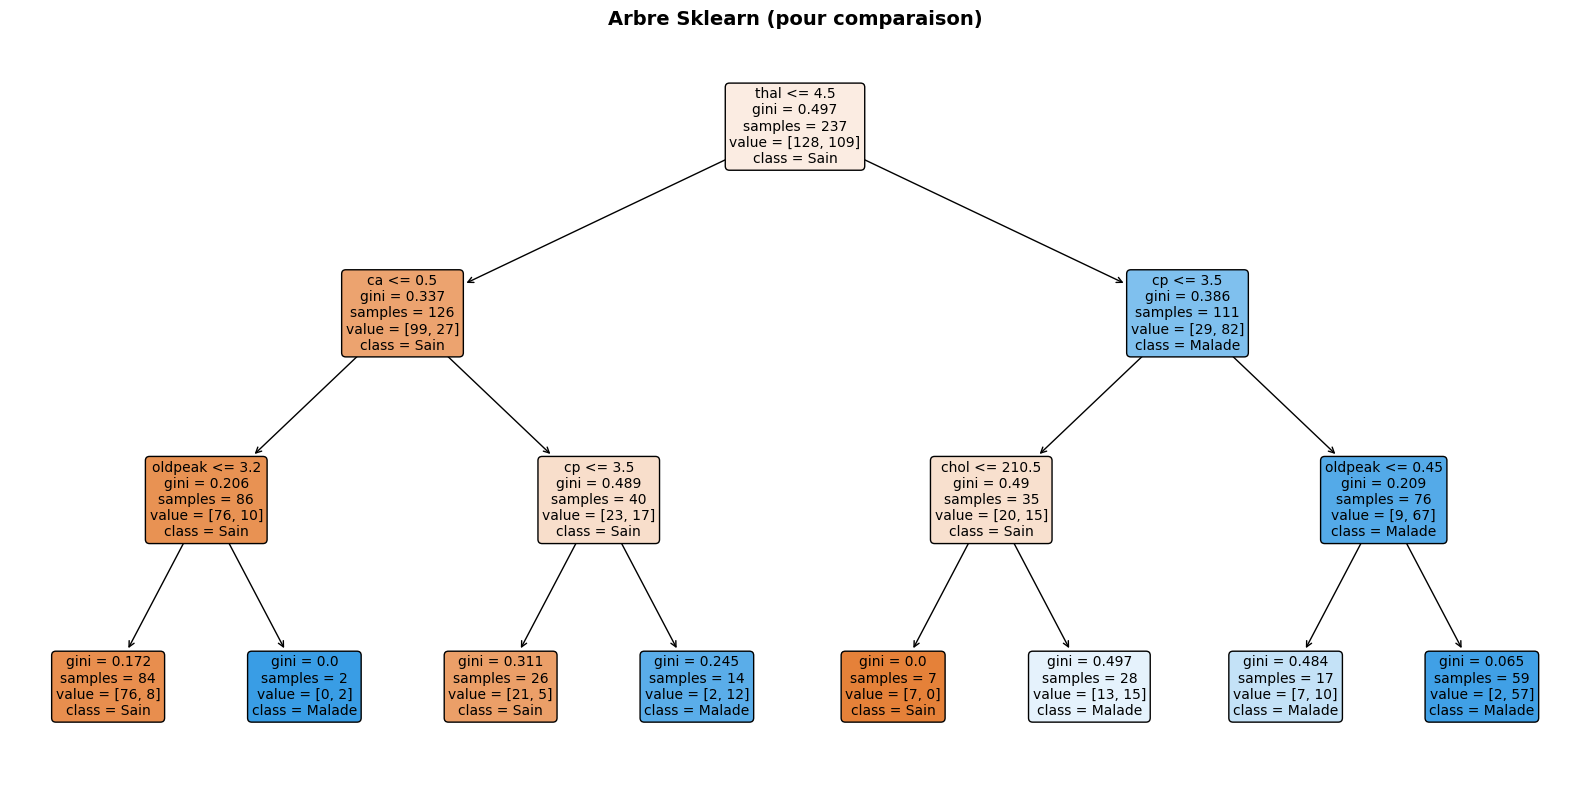

In [40]:
plt.figure(figsize=(16, 8))
plot_tree(sklearn_tree, feature_names=feature_names, class_names=['Sain', 'Malade'],
          filled=True, rounded=True, fontsize=10)
plt.title('Arbre Sklearn (pour comparaison)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Resume



In [41]:
print(f"Mon arbre (d=3)  : {acc_my:.4f}")
print(f"Sklearn (d=3)    : {acc_sklearn:.4f}")


Mon arbre (d=3)  : 0.8167
Sklearn (d=3)    : 0.8000
